In [2]:
# ==========================================
# Phase 2 - Cell 1[Top 60 精选扩充版]
# ==========================================
import pandas as pd

# 1. 加载原始数据
raw_csv = "cs2_pro_detailed_RAW.csv"
df = pd.read_csv(raw_csv)
print(f"📦 原始数据加载完毕！总人数: {len(df)}")

# 2. 核心白名单：HLTV Top 30 + 31~60名中的高价值队伍
custom_whitelist =[
    # --- Top 30 核心 ---
    "Team Vitality", "Vitality", "FURIA Esports", "FURIA", "MOUZ", 
    "Falcons", "Team Falcons", "Natus Vincere", "NAVI", "Aurora Gaming", "Aurora", 
    "PARIVISION", "Team Spirit", "Spirit", "The MongolZ", "Astralis",
    "FaZe Clan", "FaZe", "FUT Esports", "FUT", "G2 Esports", "G2", 
    "3DMAX", "Legacy", "GamerLegion", "paiN Gaming", "paiN", 
    "HEROIC", "Team Liquid", "Liquid", "B8",
    "Ninjas in Pyjamas", "NIP", "9z Team", "9z", "NRG", 
    "Gentle Mates", "Monte", "TYLOO", "BC.Game", 
    "Passion UA", "BetBoom Team", "BetBoom", "HOTU",
    
    # --- Top 31~60 玩家/导师精选高价值样本 ---
    "100 Thieves", "100T",               # 拥有 device, rain
    "Lynn Vision", "Lynn Vision Gaming", # CNCS/亚洲之光
    "MIBR", "Imperial Esports", "Imperial", # 南美赛区代表
    "FlyQuest",                          # 澳洲赛区 (jks)
    "OG",                                # cadiaN 体系
    "TDK",                               # 独联体狠人 (Ax1Le, nafany)
    "fnatic",                            # 瑞典/欧洲老牌底蕴 (KRIMZ)
    "EYEBALLERS"                         # 瑞典活化石 (JW)
]

# 3. 执行过滤
df_filtered = df[df['Team'].notna() & df['Team'].isin(custom_whitelist)].copy()

print(f"\n✨ 过滤完成！我们提纯出了 {len(df_filtered)} 名极具 AI 训练价值的现役选手！")

# 4. 瞄一眼我们的战果
display(df_filtered[['Player', 'Team', 'DPI', 'Sensitivity', 'Resolution', 'Hz', 'Scaling Mode']].head(15))

📦 原始数据加载完毕！总人数: 872

✨ 过滤完成！我们提纯出了 185 名极具 AI 训练价值的现役选手！


,Player,Team,DPI,Sensitivity,Resolution,Hz,Scaling Mode
0,ZywOo,Team Vitality,400,2,1280x960,1000,Stretched
1,ropz,Team Vitality,400,1.77,1920x1080,2000,Native
2,flameZ,Team Vitality,400,3,1280x960,1000,Stretched
3,apEX,Team Vitality,400,1.91,1280x960,1000,Stretched
4,mezii,Team Vitality,400,2.2,1280x960,2000,Stretched
5,Jamppi,Team Vitality,800,0.42,1920x1080,1000,Stretched
6,donk,Team Spirit,800,1.25,1280x960,1000,Stretched
7,sh1ro,Team Spirit,800,1.04,1152x864,2000,Black Bars
8,magixx,Team Spirit,400,1.5,1280x960,2000,Stretched
9,zont1x,Team Spirit,1600,0.525,1024x768,1000,Stretched


In [3]:
# ==========================================
# Phase 2 - Cell 2: 外科手术级数据清洗 (完美适配版)
# ==========================================
import pandas as pd
import numpy as np
import re

print("🧰 启动数据清洗流水线...")

# 1. 降维打击：只保留对我们 AI 建模有价值的核心特征
# 我们不再强求 'Mouse'，而是拿取更硬核的参数
desired_columns =[
    'Player', 'Team', 'DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 
    'Hz', 'Resolution', 'Aspect Ratio', 'Scaling Mode'
]

# 安全过滤：只保留确实存在于表里的列
actual_columns =[col for col in desired_columns if col in df_filtered.columns]
df_clean = df_filtered[actual_columns].copy()

# 2. 清洗数值列：去除文本中的逗号、空格，强制转换为 AI 认识的浮点数 (Float)
def clean_numeric_text(val):
    if pd.isna(val): 
        return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    match = re.search(r'[\d\.]+', val_str) # 用正则提取纯数字和小数点
    return float(match.group()) if match else np.nan

numeric_cols = ['DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_numeric_text)

# 3. 填补缺失值 (Imputation)：计算真实的 eDPI
# 有些人网站没给 eDPI，我们用公式 (DPI * Sensitivity) 帮他算出来！
if 'eDPI' in df_clean.columns and 'DPI' in df_clean.columns and 'Sensitivity' in df_clean.columns:
    calculated_edpi = df_clean['DPI'] * df_clean['Sensitivity']
    df_clean['eDPI'] = df_clean['eDPI'].fillna(calculated_edpi)

# 4. 拆解分辨率 (Feature Splitting)："1280x960" -> 1280 和 960
if 'Resolution' in df_clean.columns:
    res_str = df_clean['Resolution'].astype(str)
    # str.extract 配合正则表达式，瞬间拆分出宽度和高度两列！
    df_clean[['Res_Width', 'Res_Height']] = res_str.str.extract(r'(\d+)x(\d+)')
    
    # 转成数字类型
    df_clean['Res_Width'] = pd.to_numeric(df_clean['Res_Width'])
    df_clean['Res_Height'] = pd.to_numeric(df_clean['Res_Height'])

# 5. 导出 Phase 2 最终战果
final_clean_csv = "cs2_pro_cleaned_features.csv"
df_clean.to_csv(final_clean_csv, index=False)

print(f"✅ 清洗完毕！从繁杂的脏数据中，提纯出了 {len(df_clean.columns)} 列 AI 黄金特征！")
print(f"💾 数据已保存至: {final_clean_csv}")

# 查看清洗后的前 5 行完美数据
display(df_clean.head())

🧰 启动数据清洗流水线...
✅ 清洗完毕！从繁杂的脏数据中，提纯出了 12 列 AI 黄金特征！
💾 数据已保存至: cs2_pro_cleaned_features.csv


,Player,Team,DPI,Sensitivity,eDPI,Zoom Sensitivity,Hz,Resolution,Aspect Ratio,Scaling Mode,Res_Width,Res_Height
0,ZywOo,Team Vitality,400.0,2.00,800.0,1.0,1000.0,1280x960,4:3,Stretched,1280.0,960.0
1,ropz,Team Vitality,400.0,1.77,708.0,1.0,2000.0,1920x1080,16:9,Native,1920.0,1080.0
2,flameZ,Team Vitality,400.0,3.00,1200.0,1.1,1000.0,1280x960,4:3,Stretched,1280.0,960.0
3,apEX,Team Vitality,400.0,1.91,764.0,1.0,1000.0,1280x960,4:3,Stretched,1280.0,960.0
4,mezii,Team Vitality,400.0,2.20,880.0,1.0,2000.0,1280x960,4:3,Stretched,1280.0,960.0


📊 正在生成图表...


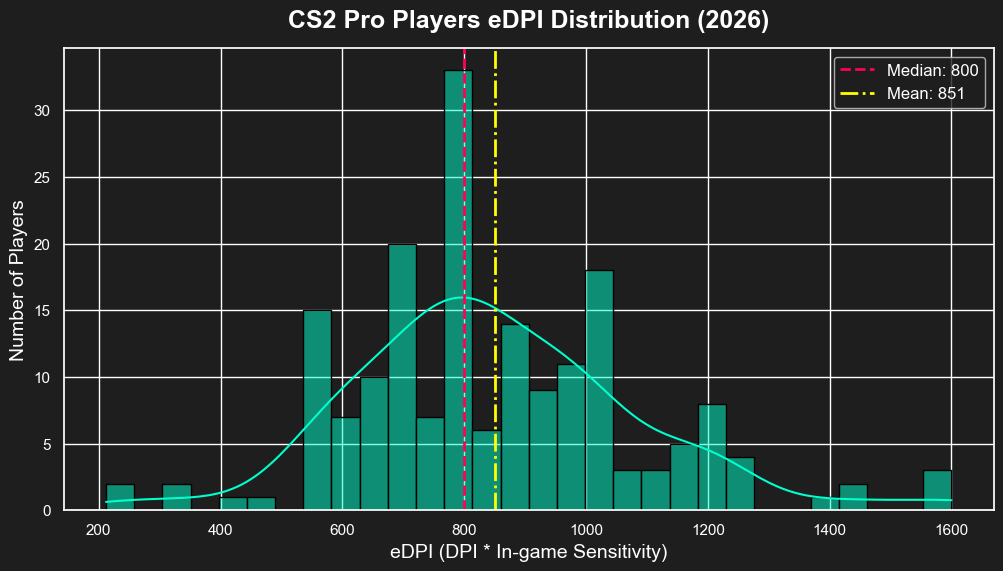


🌪️ 最高灵敏度玩家: woxic (Aurora) - eDPI: 1600.0
🐢 最低灵敏度玩家: ShahZaM (Team Liquid) - eDPI: 212.0


In [4]:
# ==========================================
# Phase 3 - Cell 1: 职业哥 eDPI 核心分布揭秘
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 正在生成图表...")

# 读取我们刚洗好的数据
df_clean = pd.read_csv("cs2_pro_cleaned_features.csv")

# 设置图表风格 (电竞暗黑风)
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor":"#1e1e1e", "text.color":"white", "axes.labelcolor":"white", "xtick.color":"white", "ytick.color":"white"})

# 创建一个 10x6 英寸的画布
plt.figure(figsize=(12, 6))

# 剔除那些 eDPI 异常高的数据（比如 > 2500 的，可能是极端个例或者填错的数据），让图表更好看
valid_edpi = df_clean[df_clean['eDPI'] < 2500]['eDPI']

# 绘制带有核密度估计 (KDE) 曲线的直方图
ax = sns.histplot(valid_edpi, bins=30, kde=True, color='#00ffcc', edgecolor='black')

# 计算一些关键统计量
median_edpi = valid_edpi.median()
mean_edpi = valid_edpi.mean()

# 在图上画出中位数和平均值的垂直线
plt.axvline(median_edpi, color='#ff0055', linestyle='--', linewidth=2, label=f'Median: {median_edpi:.0f}')
plt.axvline(mean_edpi, color='#ffff00', linestyle='-.', linewidth=2, label=f'Mean: {mean_edpi:.0f}')

# 设置标题和标签
plt.title('CS2 Pro Players eDPI Distribution (2026)', fontsize=18, fontweight='bold', color='white', pad=15)
plt.xlabel('eDPI (DPI * In-game Sensitivity)', fontsize=14)
plt.ylabel('Number of Players', fontsize=14)
plt.legend(fontsize=12)

# 显示图表
plt.show()

# 顺便找出 eDPI 最高和最低的极端分子！
max_edpi_player = df_clean.loc[df_clean['eDPI'].idxmax()]
min_edpi_player = df_clean.loc[df_clean['eDPI'].idxmin()]
print(f"\n🌪️ 最高灵敏度玩家: {max_edpi_player['Player']} ({max_edpi_player['Team']}) - eDPI: {max_edpi_player['eDPI']}")
print(f"🐢 最低灵敏度玩家: {min_edpi_player['Player']} ({min_edpi_player['Team']}) - eDPI: {min_edpi_player['eDPI']}")

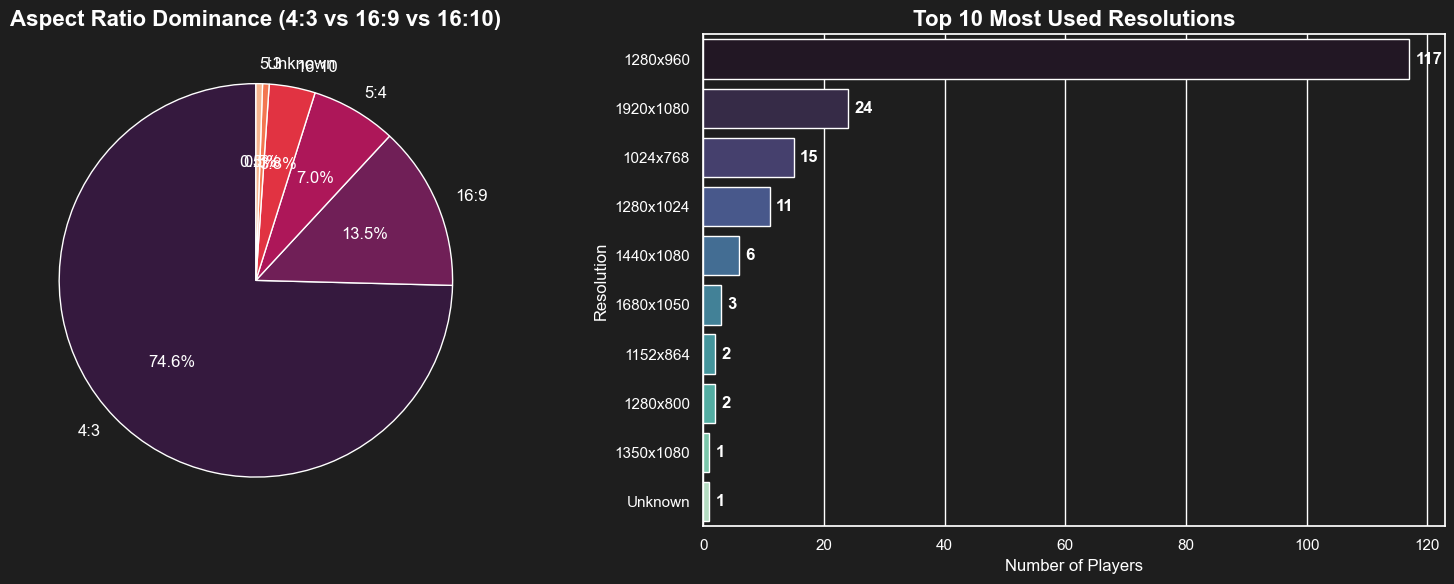

In [6]:
# ==========================================
# Phase 3 - Cell 2: 分辨率与长宽比的真实占比
# ==========================================

# 创建一个 1x2 的子图排版 (左边画长宽比，右边画具体分辨率)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：长宽比 (Aspect Ratio) 饼图 ---
aspect_counts = df_clean['Aspect Ratio'].value_counts()
axes[0].pie(aspect_counts, labels=aspect_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('rocket'), startangle=90, textprops={'fontsize': 12, 'color': 'white'})
axes[0].set_title('Aspect Ratio Dominance (4:3 vs 16:9 vs 16:10)', fontsize=16, fontweight='bold')

# --- 右图：具体分辨率 (Resolution) 条形图 ---
# 统计出现次数最多的前 10 个分辨率
res_counts = df_clean['Resolution'].value_counts().head(10)
sns.barplot(x=res_counts.values, y=res_counts.index, ax=axes[1], hue=res_counts.index, palette='mako', legend=False)
axes[1].set_title('Top 10 Most Used Resolutions', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Number of Players', fontsize=12)
axes[1].set_ylabel('Resolution', fontsize=12)

# 给右图的条形加上具体的数字标签
for i, v in enumerate(res_counts.values):
    axes[1].text(v + 1, i, str(v), color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

🤖 正在启动 AI 聚类引擎...


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\starfie1d\.conda\envs\cs2_data\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\starfie1d\.conda\envs\cs2_data\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\starfie1d\.conda\envs\cs2_data\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\starfie1d\.conda\envs\cs2_data\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xcb in position 171: invalid continuation byte


✅ AI 学习完毕！已经为所有选手自动分配了流派。


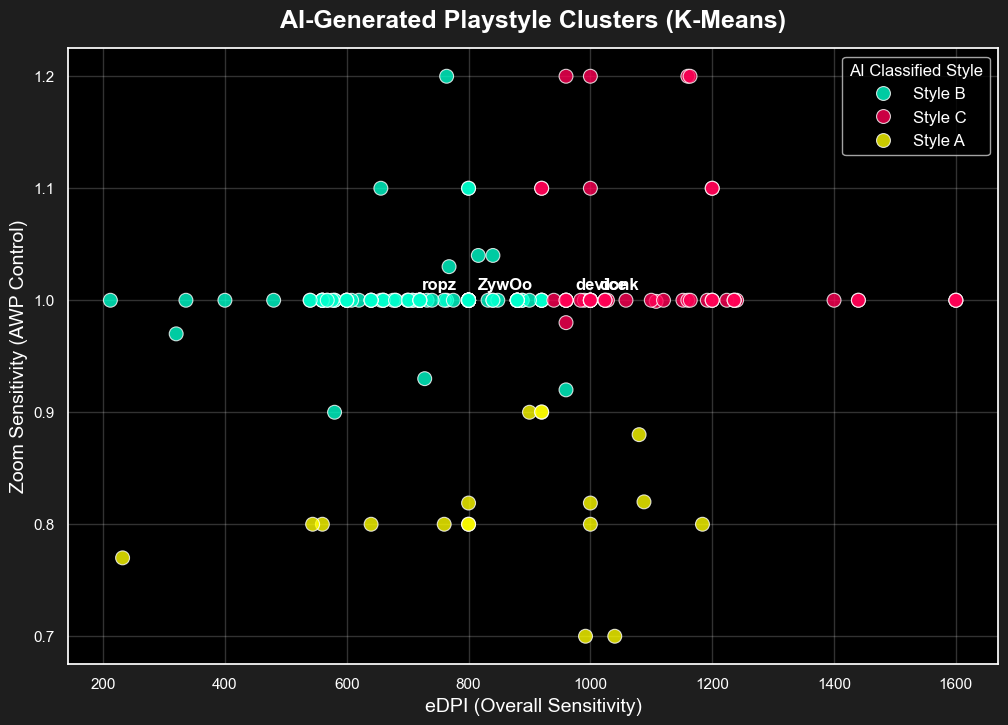


📊 各流派的参数平均值：
            eDPI  Zoom Sensitivity
Style                             
Style A   847.78              0.81
Style B   727.30              1.00
Style C  1117.06              1.02


In [7]:
# ==========================================
# Phase 4 - Cell 1: AI 无监督学习 (K-Means 聚类)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("🤖 正在启动 AI 聚类引擎...")

# 1. 准备数据：提取我们要让 AI 分析的特征
features = ['eDPI', 'Zoom Sensitivity']

# 清除这两列中有空值 (NaN) 的行，因为 AI 无法处理空数据
df_ai = df_clean.dropna(subset=features).copy()

# ⚠️ 剔除 eDPI 异常高的数据 (比如 > 2000)，防止极端个例带偏 AI 模型
df_ai = df_ai[df_ai['eDPI'] < 2000]

# 2. 数据标准化 (Standardization) -极其关键！
# 因为 eDPI 动辄 800、1000，而 Zoom Sens 只有 1.0 左右。
# 如果不缩放，AI 会认为 eDPI 的重要性是 Zoom 的 1000 倍！
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_ai[features])

# 3. 召唤 AI：K-Means 算法
# 我们设定 n_clusters=3，让 AI 自动把选手分为 3 种流派
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 让 AI 进行学习并打上标签 (0, 1, 或 2)
df_ai['Cluster'] = kmeans.fit_predict(scaled_data)

# 给 AI 分出的类别起个响亮的名字
cluster_names = {
    0: 'Style A',
    1: 'Style B',
    2: 'Style C'
}
df_ai['Style'] = df_ai['Cluster'].map(cluster_names)

print("✅ AI 学习完毕！已经为所有选手自动分配了流派。")

# 4. 可视化 AI 的思考结果
plt.figure(figsize=(12, 8))
plt.style.use('dark_background')

# 用散点图画出分类结果，不同的流派用不同颜色
sns.scatterplot(
    data=df_ai, 
    x='eDPI', 
    y='Zoom Sensitivity', 
    hue='Style', 
    palette=['#00ffcc', '#ff0055', '#ffff00'], 
    s=100, # 点的大小
    alpha=0.8, # 透明度
    edgecolor='white'
)

# 在图上标出一些著名选手的名字，看看他们被 AI 分到了哪一派！
# 你可以把这里的名字换成你喜欢的选手
star_players =['ZywOo', 'donk', 'NiKo', 'm0NESY', 'device', 'ropz']
for player in star_players:
    player_data = df_ai[df_ai['Player'] == player]
    if not player_data.empty:
        plt.text(
            player_data['eDPI'].values[0] + 15, 
            player_data['Zoom Sensitivity'].values[0] + 0.01, 
            player, 
            color='white', 
            fontsize=12, 
            fontweight='bold'
        )

plt.title('AI-Generated Playstyle Clusters (K-Means)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('eDPI (Overall Sensitivity)', fontsize=14)
plt.ylabel('Zoom Sensitivity (AWP Control)', fontsize=14)
plt.legend(title='AI Classified Style', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

# 打印出每个流派的具体统计数据
print("\n📊 各流派的参数平均值：")
print(df_ai.groupby('Style')[features].mean().round(2))

🖥️ 正在读取原始数据并提取高级画质设置...


C:\Users\starfie1d\AppData\Local\Temp\ipykernel_21376\4193668991.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=shadow_data, ax=axes[0, 0], order=shadow_data.value_counts().index, palette='magma')
C:\Users\starfie1d\AppData\Local\Temp\ipykernel_21376\4193668991.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=msaa_data, ax=axes[0, 1], order=msaa_data.value_counts().index, palette='viridis')
C:\Users\starfie1d\AppData\Local\Temp\ipykernel_21376\4193668991.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=particle_data

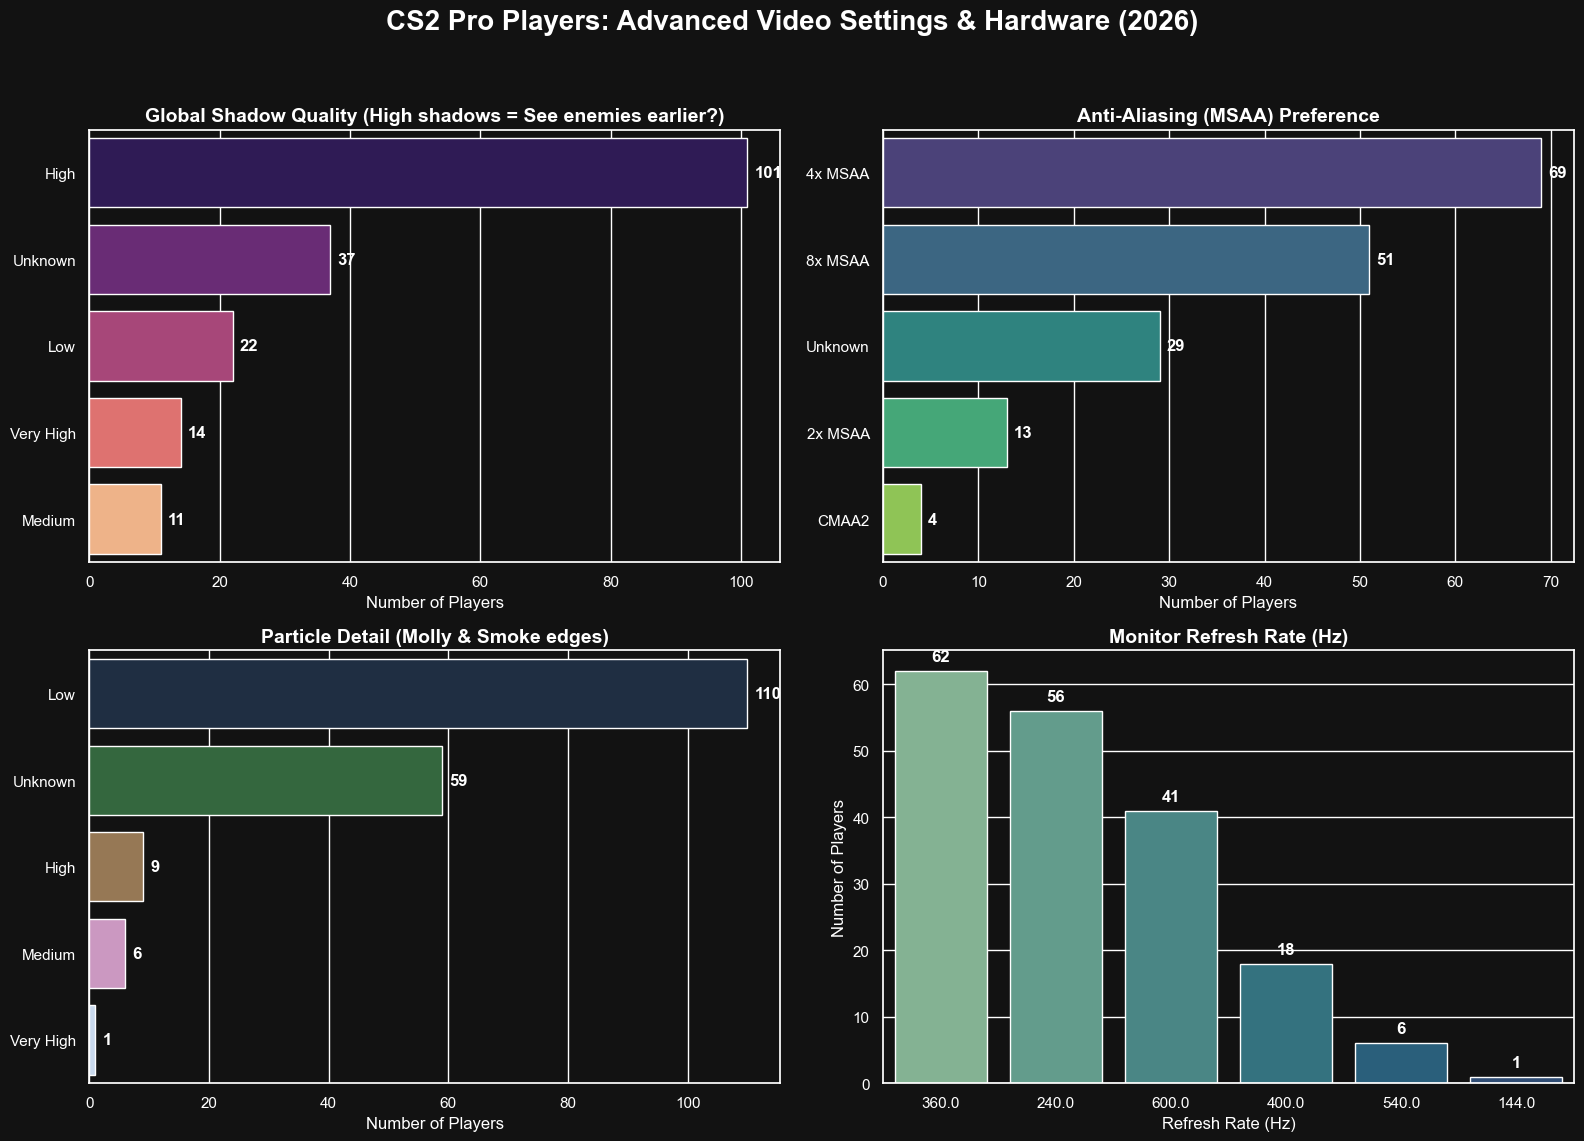

In [1]:
# ==========================================
# Phase 5 - Cell 1: 职业哥高级视频设置与刷新率大揭秘
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🖥️ 正在读取原始数据并提取高级画质设置...")

# 1. 我们直接读取第一阶段抓取的最全的 RAW 数据，并用之前的白名单过滤
df_raw = pd.read_csv("cs2_pro_detailed_RAW.csv")
top_30_teams =[
    "Team Vitality", "Vitality", "FURIA Esports", "FURIA", "MOUZ", "Falcons", "Team Falcons", "Natus Vincere", "NAVI", "Aurora Gaming", "Aurora", "PARIVISION", "Team Spirit", "Spirit", "The MongolZ", "Astralis", "FaZe Clan", "FaZe", "FUT Esports", "FUT", "G2 Esports", "G2", "3DMAX", "Legacy", "GamerLegion", "paiN Gaming", "paiN", "HEROIC", "Team Liquid", "Liquid", "B8", "Ninjas in Pyjamas", "NIP", "9z Team", "9z", "NRG", "Gentle Mates", "Monte", "TYLOO", "BC.Game", "Passion UA", "BetBoom Team", "BetBoom", "HOTU", "100 Thieves", "100T", "Lynn Vision", "Lynn Vision Gaming", "MIBR", "Imperial Esports", "Imperial", "FlyQuest", "OG", "TDK", "fnatic", "EYEBALLERS"
]
df_pro = df_raw[df_raw['Team'].notna() & df_raw['Team'].isin(top_30_teams)].copy()

# 2. 设置图表暗黑电竞风格
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor":"#121212", "text.color":"white", "axes.labelcolor":"white", "xtick.color":"white", "ytick.color":"white"})

# 3. 准备一个 2x2 的大画布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CS2 Pro Players: Advanced Video Settings & Hardware (2026)', fontsize=20, fontweight='bold', y=0.98)

# ----------------- 图 1: 全局阴影质量 (Global Shadow Quality) -----------------
# 过滤掉空值
shadow_data = df_pro['Global Shadow Quality'].dropna()
sns.countplot(y=shadow_data, ax=axes[0, 0], order=shadow_data.value_counts().index, palette='magma')
axes[0, 0].set_title('Global Shadow Quality (High shadows = See enemies earlier?)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Players')
axes[0, 0].set_ylabel('')

# ----------------- 图 2: 抗锯齿 (Multisampling Anti-Aliasing Mode) -----------------
msaa_data = df_pro['Multisampling Anti-Aliasing Mode'].dropna()
sns.countplot(y=msaa_data, ax=axes[0, 1], order=msaa_data.value_counts().index, palette='viridis')
axes[0, 1].set_title('Anti-Aliasing (MSAA) Preference', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Players')
axes[0, 1].set_ylabel('')

# ----------------- 图 3: 粒子特效 (Particle Detail) -----------------
particle_data = df_pro['Particle Detail'].dropna()
sns.countplot(y=particle_data, ax=axes[1, 0], order=particle_data.value_counts().index, palette='cubehelix')
axes[1, 0].set_title('Particle Detail (Molly & Smoke edges)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Players')
axes[1, 0].set_ylabel('')

# ----------------- 图 4: 显示器刷新率 (Refresh Rate) -----------------
# 刷新率可能带 "Hz"，我们清理一下变纯数字
def clean_hz(val):
    if pd.isna(val): return None
    import re
    match = re.search(r'\d+', str(val))
    return int(match.group()) if match else None

hz_data = df_pro['Refresh Rate'].apply(clean_hz).dropna()
sns.countplot(x=hz_data, ax=axes[1, 1], order=hz_data.value_counts().index, palette='crest')
axes[1, 1].set_title('Monitor Refresh Rate (Hz)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Refresh Rate (Hz)')
axes[1, 1].set_ylabel('Number of Players')

# 加上数字标签
for ax in axes.flat:
    for p in ax.patches:
        if ax == axes[1, 1]: # 如果是柱状图 (X轴)
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')
        else: # 如果是条形图 (Y轴)
            ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', color='white', fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [2]:
# ==========================================
# Phase 5 - Cell 2: 终极大一统 - 5大维度全量数据清洗
# ==========================================
import pandas as pd
import numpy as np
import re

print("🏗️ 正在构建 CS2 职业选手 5大维度 Master 总表...")

# 1. 读取原始数据及白名单过滤 (沿用之前的纯净名单)
df_raw = pd.read_csv("cs2_pro_detailed_RAW.csv")
top_30_teams =[
    "Team Vitality", "FaZe Clan", "Natus Vincere", "Team Spirit", "MOUZ", 
    "G2 Esports", "Virtus.pro", "Astralis", "Complexity", "HEROIC", 
    "Cloud9", "ENCE", "Team Liquid", "Falcons", "Ninjas in Pyjamas", 
    "BIG", "The MongolZ", "FURIA", "GamerLegion", "SAW", "Eternal Fire",
    "100 Thieves", "Lynn Vision", "MIBR", "Imperial Esports", "FlyQuest", 
    "OG", "TDK", "fnatic", "EYEBALLERS", "Aurora Gaming", "PARIVISION",
    "FUT Esports", "3DMAX", "Legacy", "paiN Gaming", "9z Team", "NRG",
    "Gentle Mates", "Monte", "TYLOO", "BC.Game", "Passion UA", "BetBoom Team", "HOTU"
]
df = df_raw[df_raw['Team'].notna() & df_raw['Team'].isin(top_30_teams)].copy()

# 2. 定义 5 大核心维度的列名清单 (依据你的专业整理)
identity_cols = ['Player', 'Team']

mouse_cols =['DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz', 'Windows Sensitivity']

video_cols =['Resolution', 'Aspect Ratio', 'Scaling Mode', 'Refresh Rate', 'Brightness', 
              'Display Mode', 'Boost Player Contrast', 'Multisampling Anti-Aliasing Mode', 
              'Global Shadow Quality', 'Texture Filtering Mode']

crosshair_cols =['Style', 'Length', 'Thickness', 'Gap', 'Outline', 'Color', 'Dot']

viewmodel_cols =['FOV', 'Offset X', 'Offset Y', 'Offset Z', 'Presetpos']

radar_cols =['Radar Centers The Player', 'Radar is Rotating', 'Radar Map Zoom', 'HUD Scale', 'HUD Color']

# 合并所有需要的列
all_desired_cols = identity_cols + mouse_cols + video_cols + crosshair_cols + viewmodel_cols + radar_cols

# 过滤掉原表中没有成功抓到的列，防止报错
actual_cols =[col for col in all_desired_cols if col in df.columns]
df_master = df[actual_cols].copy()

# ==========================================
# 3. 硬核数据清洗 (Regex 魔法)
# ==========================================

# 提取纯数字 (支持正负数和小数，比如 Gap 的 -3，或者 Brightness 的 93%)
def extract_number(val):
    if pd.isna(val): return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    # 正则表达式：匹配可选的正负号 [-+]?，匹配数字 \d*，匹配可选的小数点 \.?，匹配数字 \d+
    match = re.search(r'[-+]?\d*\.?\d+', val_str)
    return float(match.group()) if match else np.nan

# 需要强制转成数字的列
numeric_targets =['DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz', 'Windows Sensitivity',
                   'Refresh Rate', 'Brightness', 'Length', 'Thickness', 'Gap', 
                   'FOV', 'Offset X', 'Offset Y', 'Offset Z', 'Presetpos', 
                   'Radar Map Zoom', 'HUD Scale']

for col in numeric_targets:
    if col in df_master.columns:
        df_master[col] = df_master[col].apply(extract_number)

# 重新计算并补全 eDPI
if 'eDPI' in df_master.columns and 'DPI' in df_master.columns and 'Sensitivity' in df_master.columns:
    df_master['eDPI'] = df_master['eDPI'].fillna(df_master['DPI'] * df_master['Sensitivity'])

# 拆分分辨率 (1280x960 -> 1280, 960)
if 'Resolution' in df_master.columns:
    res_str = df_master['Resolution'].astype(str)
    df_master[['Res_Width', 'Res_Height']] = res_str.str.extract(r'(\d+)x(\d+)')
    df_master['Res_Width'] = pd.to_numeric(df_master['Res_Width'])
    df_master['Res_Height'] = pd.to_numeric(df_master['Res_Height'])

# 4. 保存为终极 Master CSV
master_csv_path = "cs2_pro_master_cleaned.csv"
df_master.to_csv(master_csv_path, index=False, encoding='utf-8-sig')

print(f"✅ Master 总表构建完成！共计 {len(df_master)} 名顶级选手，{len(df_master.columns)} 个黄金特征。")
print(f"💾 数据已保存至: {master_csv_path}")

# 预览前 3 行数据看看有多壮观
pd.set_option('display.max_columns', None) # 强制 Jupyter 显示所有列
display(df_master.head(3))

🏗️ 正在构建 CS2 职业选手 5大维度 Master 总表...
✅ Master 总表构建完成！共计 210 名顶级选手，37 个黄金特征。
💾 数据已保存至: cs2_pro_master_cleaned.csv


,Player,Team,DPI,Sensitivity,eDPI,Zoom Sensitivity,Hz,Windows Sensitivity,Resolution,Aspect Ratio,Scaling Mode,Refresh Rate,Brightness,Display Mode,Boost Player Contrast,Multisampling Anti-Aliasing Mode,Global Shadow Quality,Texture Filtering Mode,Style,Length,Thickness,Gap,Outline,Color,Dot,FOV,Offset X,Offset Y,Offset Z,Presetpos,Radar Centers The Player,Radar is Rotating,Radar Map Zoom,HUD Scale,HUD Color,Res_Width,Res_Height
0,ZywOo,Team Vitality,400.0,2.00,800.0,1.0,1000.0,6.0,1280x960,4:3,Stretched,360.0,93.0,Fullscreen,Enabled,4x MSAA,High,Anisotropic 4x,Classic Static,1.5,0.1,-2.6,No,Custom,No,68.0,2.5,0.0,-1.5,2.0,Yes,Yes,0.70,1.0,Team Color,1280.0,960.0
1,ropz,Team Vitality,400.0,1.77,708.0,1.0,2000.0,6.0,1920x1080,16:9,Native,600.0,93.0,Fullscreen,Enabled,2x MSAA,Low,Bilinear,Classic Static,2.0,0.5,-3.0,No,Green,No,68.0,2.5,0.0,-1.5,2.0,Yes,Yes,0.65,1.0,Team Color,1920.0,1080.0
2,flameZ,Team Vitality,400.0,3.00,1200.0,1.1,1000.0,6.0,1280x960,4:3,Stretched,360.0,119.0,Fullscreen,Enabled,4x MSAA,High,Bilinear,Legacy,1.5,0.5,-2.0,No,Cyan,Yes,68.0,2.5,0.0,-1.5,2.0,Yes,Yes,0.30,1.0,White,1280.0,960.0


In [3]:
# ==========================================
# 终极数据清洗 (Phase 2 - 完美收官版)
# 融合 2026 最新 39 支顶级战队现役名单 + 强制队伍重分配
# ==========================================
import pandas as pd
import numpy as np
import re

print("🏗️ 正在构建 2026 现役职业选手终极 Master 总表...")

# 1. 直接读取原始的 RAW 数据
df_raw = pd.read_csv("cs2_pro_detailed_RAW.csv")
# 粗略将没用的字符转为空值
df_raw.replace(['Unknown', 'unknown', 'None', '', ' '], np.nan, inplace=True)

# 2. 👑 2026 年 3 月真理名单 (Source of Truth) - 涵盖 39 支核心战队 (195 名选手)
sot_rosters = {
    # Top 30 核心队伍名单
    "Team Vitality":["apEX", "ropz", "ZywOo", "flameZ", "mezii"],
    "FURIA":["FalleN", "yuurih", "YEKINDAR", "KSCERATO", "molodoy"],
    "MOUZ":["Brollan", "torzsi", "Spinx", "Jimpphat", "xertioN"],
    "Falcons": ["NiKo", "TeSeS", "m0NESY", "kyxsan", "kyousuke"],
    "Natus Vincere":["Aleksib", "iM", "b1t", "w0nderful", "makazze"],
    "Aurora":["MAJ3R", "XANTARES", "woxic", "soulfly", "Wicadia"],
    "PARIVISION":["Jame", "BELCHONOKK", "xiELO", "nota", "zweih"],
    "Team Spirit":["sh1ro", "magixx", "tN1R", "zont1x", "donk"],
    "The MongolZ":["bLitz", "Techno", "mzinho", "910", "cobrazera"],
    "Astralis":["HooXi", "phzy", "jabbi", "Staehr", "ryu"],
    "FaZe Clan":["karrigan", "frozen", "Twistzz", "broky", "jcobbb"],
    "FUT Esports":["dem0n", "lauNX", "Krabeni", "cmtry", "dziugss"],
    "G2 Esports":["huNter-", "NertZ", "SunPayus", "HeavyGod", "MATYS"],
    "3DMAX":["Maka", "Lucky", "misutaaa", "Ex3rcice", "Graviti"],
    "Legacy":["arT", "dumau", "latto", "n1ssim", "saadzin"],
    "GamerLegion":["Snax", "REZ", "Tauson", "PR", "hypex"],
    "paiN Gaming":["vsm", "biguzera", "piriajr", "nqz", "snow"],
    "HEROIC":["xfl0ud", "nilo", "susp", "Chr1zN", "Alkaren"],
    "Team Liquid":["NAF", "EliGE", "malbsMd", "siuhy", "ultimate"],
    "B8":["alex666", "npl", "kensizor", "esenthial", "s1zzi"],
    "Ninjas in Pyjamas":["Snappi", "sjuush", "r1nkle", "xKacpersky", "cairne"],
    "9z Team":["max", "dgt", "meyern", "luchov", "HUASOPEEK"],
    "NRG":["nitr0", "Sonic", "oSee", "Grim", "br0"],
    "Gentle Mates":["alex", "mopoz", "sausol", "dav1g", "MartinezSa"],
    "Monte":["Rainwaker", "Bymas", "afro", "Gizmy", "AZUWU"],
    "TYLOO":["JamYoung", "Jee", "Mercury", "Moseyuh", "Zero"],
    "BC.Game":["MUTiRiS", "s1mple", "electroNic", "aragornN", "krazy"],
    "Passion UA":["JT", "try", "Senzu", "Kvem", "nicx"],
    "BetBoom":["Boombl4", "s1ren", "d1Ledez", "ArtFr0st", "Magnojez"],
    "HOTU":["n0rb3r7", "dukefissura", "mizu", "kAlash", "frontales"],
    
    # Top 31~60 精选高价值队伍名单
    "MIBR":["LNZ", "brnz4n", "insani", "venomzera", "kl1m"],
    "Imperial": ["chelo", "VINI", "decenty", "levi", "noway"],
    "100 Thieves":["device", "rain", "Ag1l", "sirah", "poiii"],
    "fnatic":["KRIMZ", "fEAR", "jambo", "jackasmo", "Br4tkO"],
    "Lynn Vision":["Westmelon", "z4KR", "Starry", "EmiliaQAQ", "C4LLM3SU3"],
    "OG":["cadiaN", "bodyy", "spooke", "arrozdoce", "adamb"],
    "FlyQuest": ["jks", "INS", "Vexite", "nettik", "story"],
    "EYEBALLERS":["JW", "maxster", "Ro1f", "bobeksde", "dex"],
    "TDK":["zorte", "Ax1Le", "nafany", "sugaR", "Xant3r"]
}

# 3. 🎯 核心逻辑：不依赖原表队伍名，只靠选手名字抓人！
active_players_data =[]
for team, players in sot_rosters.items():
    players_lower =[str(p).lower() for p in players] # 转小写防报错
    
    # 在原表中抓取这些名字的数据
    team_data = df_raw[df_raw['Player'].str.lower().isin(players_lower)].copy()
    
    # 强制重新分配队伍！(比如 s1mple 就算在旧表里写着 NAVI，这里也会被强行改成 BC.Game)
    if not team_data.empty:
        team_data['Team'] = team 
    
    active_players_data.append(team_data)

# 合并，并剔除可能因为爬虫重复导致的多余行
df_active = pd.concat(active_players_data, ignore_index=True)
df_active = df_active.drop_duplicates(subset=['Player'])

# 4. 提取 5 大核心维度列
desired_cols =[
    'Player', 'Team', # 身份
    'DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz', 'Windows Sensitivity', # 鼠标
    'Resolution', 'Aspect Ratio', 'Scaling Mode', 'Refresh Rate', 'Brightness', 'Display Mode', 'Multisampling Anti-Aliasing Mode', 'Global Shadow Quality', 'Texture Filtering Mode', # 视频
    'Style', 'Length', 'Thickness', 'Gap', 'Outline', 'Color', 'Dot', # 准星
    'FOV', 'Offset X', 'Offset Y', 'Offset Z', 'Presetpos', # 视角
    'Radar Centers The Player', 'Radar is Rotating', 'Radar Map Zoom', 'HUD Scale', 'HUD Color' # 雷达界面
]
actual_cols = [col for col in desired_cols if col in df_active.columns]
df_master = df_active[actual_cols].copy()

# 5. 硬核数据清理 (Regex 提取纯数字)
def extract_number(val):
    if pd.isna(val): return np.nan
    match = re.search(r'[-+]?\d*\.?\d+', str(val).replace(',', '').replace(' ', ''))
    return float(match.group()) if match else np.nan

numeric_targets =['DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz', 'Windows Sensitivity', 'Refresh Rate', 'Brightness', 'Length', 'Thickness', 'Gap', 'FOV', 'Offset X', 'Offset Y', 'Offset Z', 'Presetpos', 'Radar Map Zoom', 'HUD Scale']

for col in numeric_targets:
    if col in df_master.columns:
        df_master[col] = df_master[col].apply(extract_number)

# 补全 eDPI
if 'eDPI' in df_master.columns and 'DPI' in df_master.columns and 'Sensitivity' in df_master.columns:
    df_master['eDPI'] = df_master['eDPI'].fillna(df_master['DPI'] * df_master['Sensitivity'])

# 拆解分辨率 (1920x1080 -> 1920 和 1080)
if 'Resolution' in df_master.columns:
    res_str = df_master['Resolution'].astype(str)
    df_master[['Res_Width', 'Res_Height']] = res_str.str.extract(r'(\d+)x(\d+)')
    df_master['Res_Width'] = pd.to_numeric(df_master['Res_Width'])
    df_master['Res_Height'] = pd.to_numeric(df_master['Res_Height'])

# 6. 保存最完美的终极数据集
final_csv = "cs2_pro_2026_Active_Master.csv"
df_master.to_csv(final_csv, index=False, encoding='utf-8-sig')

print(f"✅ Master 总表构建完美收官！共精准捞取 {len(df_master)} 名 2026 现役首发！")
print(f"💾 终极纯金数据已封存至: {final_csv}")

# 预览战果 (看看 s1mple 是不是在 BC.Game！)
display(df_master[df_master['Player'].str.lower() == 's1mple'][['Player', 'Team', 'DPI', 'Sensitivity', 'eDPI']])

🏗️ 正在构建 2026 现役职业选手终极 Master 总表...
✅ Master 总表构建完美收官！共精准捞取 189 名 2026 现役首发！
💾 终极纯金数据已封存至: cs2_pro_2026_Active_Master.csv


C:\Users\starfie1d\AppData\Local\Temp\ipykernel_21376\604557707.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_raw.replace(['Unknown', 'unknown', 'None', '', ' '], np.nan, inplace=True)


,Player,Team,DPI,Sensitivity,eDPI
127,s1mple,BC.Game,400.0,3.09,1236.0
